# Segmenting Telecom Subscribers with k-Means Clustering


## Executive Summary

A telecom carrier wants to group its postpaid subscriber base into behavioral segments so it can target retention offers and right-size data plans. This notebook generates a synthetic subscriber-usage dataset, then runs a complete k-means segmentation pipeline in Base SAS: standardize the usage drivers with **PROC STDIZE**, choose the cluster count by comparing the pseudo-F statistic across candidate k with **PROC FASTCLUS**, fit a FREQ-weighted final model that scores every subscriber, and export the learned centroids so next month's snapshot can be scored without re-clustering. The result is a reusable segmentation that maps raw usage telemetry onto a retention playbook.

## Data Sources

**Synthetic dataset: `WORK.SUBSCRIBERS`** (100 postpaid mobile subscribers, generated inline with `call streaminit(20260531)`)

| Variable | Type | Role | Description |
|----------|------|------|-------------|
| `cust_id` | Char | ID | Subscriber identifier (e.g. `SUB000123`) |
| `tenure_months` | Num | Interval input | Months the line has been active (1-72) |
| `data_gb` | Num | Interval input | Average monthly mobile data used, in GB |
| `voice_min` | Num | Interval input | Average monthly voice minutes |
| `intl_min` | Num | Interval input | Average monthly international minutes |
| `support_calls` | Num | Interval input | Care/support contacts in the last 90 days |
| `monthly_charge` | Num | Interval input | Current monthly bill, in dollars |
| `plan_tier` | Char | Profiling | Rate plan: `Basic`, `Plus`, or `Unlimited` |
| `n_lines` | Num | FREQ weight | Lines on the account |

Three latent behavioral profiles are embedded in the generator - *light/value*, *heavy-data/streaming*, and *high-touch/at-risk* - so the clustering has real structure to recover. The interval drivers feed the k-means model; `plan_tier` is held out for post-hoc profiling, and `n_lines` weights each account by its number of lines. No external files or network access are used.

## Behavioral segmentation in five steps

Mobile carriers carry millions of postpaid lines, and a one-size-fits-all retention strategy wastes margin on customers who would stay anyway while missing the ones about to churn. **Behavioral segmentation** turns raw usage telemetry into a handful of actionable customer types: *light/value* users who are price-sensitive, *heavy-data streamers* who are good upsell targets, and *high-touch/at-risk* accounts that need proactive care.

This notebook builds the segmentation with `PROC FASTCLUS`, SAS's k-means (disjoint cluster) procedure. We will:

1. Generate a synthetic but realistic subscriber-usage dataset.
2. Put the usage drivers on a common scale with **PROC STDIZE**.
3. **Choose the number of clusters** by comparing the pseudo-F statistic across candidate k.
4. Fit a FREQ-weighted final model that **scores** every subscriber and profiles the segments.
5. **Export the learned centroids** so the model can be re-applied to next month's snapshot.

## Step 1 - Generate a synthetic subscriber base

We simulate 100 postpaid subscribers. Each is drawn from one of three latent profiles with different usage signatures, so there is genuine cluster structure to recover. We fix the stream with `call streaminit` for reproducibility and clamp the simulated values to plausible ranges with `max`/`min`/`round`.

The nominal `plan_tier` is correlated with the latent profile (streamers skew toward *Unlimited*; value users toward *Basic*), and `n_lines` will later serve as a FREQ weight so multi-line family accounts count proportionally.

In [1]:
data subscribers;
    call streaminit(20260531);
    length cust_id $9 plan_tier $9;
    do i = 1 to 100;
        cust_id = cats('SUB', put(i, z6.));

        /* Three latent behavioral profiles, ~unequal prevalence */
        u = rand('uniform');
        if u < 0.45 then profile = 1;        /* light / value        */
        else if u < 0.80 then profile = 2;   /* heavy-data streamer   */
        else profile = 3;                    /* high-touch / at-risk  */

        if profile = 1 then do;
            tenure_months  = round(min(72, max(1, rand('normal', 30, 14))));
            data_gb        = max(0.2, rand('normal', 3,  1.5));
            voice_min      = max(0,   rand('normal', 180, 60));
            intl_min       = max(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = max(15, rand('normal', 45, 8));
        end;
        else if profile = 2 then do;
            tenure_months  = round(min(72, max(1, rand('normal', 40, 16))));
            data_gb        = max(0.2, rand('normal', 22, 6));
            voice_min      = max(0,   rand('normal', 320, 90));
            intl_min       = max(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = max(15, rand('normal', 85, 12));
        end;
        else do;
            tenure_months  = round(min(72, max(1, rand('normal', 12, 8))));
            data_gb        = max(0.2, rand('normal', 9,  4));
            voice_min      = max(0,   rand('normal', 240, 80));
            intl_min       = max(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = max(15, rand('normal', 70, 18));
        end;

        /* Plan tier correlated with profile */
        p = rand('uniform');
        if profile = 1 then
            plan_tier = ifc(p < 0.70, 'Basic', ifc(p < 0.95, 'Plus', 'Unlimited'));
        else if profile = 2 then
            plan_tier = ifc(p < 0.65, 'Unlimited', ifc(p < 0.90, 'Plus', 'Basic'));
        else
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Unlimited', 'Basic'));

        /* Lines on the account: most are single-line */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Round monetary / usage values to realistic precision */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        output;
    end;
    drop i u p profile;
run;

proc print data=subscribers(obs=10) noobs;
    title 'Sample of Synthetic Subscriber Usage Records';
run;

                                      Sample of Synthetic Subscriber Usage Records                                      

  CUST_ID  PLAN_TIER  TENURE_MONTHS  DATA_GB  VOICE_MIN  INTL_MIN  SUPPORT_CALLS  MONTHLY_CHARGE  N_LINES
SUB000001  Basic                 15      9.7        114         5             11           57.07        2
SUB000002  Basic                 39      0.6        214         2              1           35.88        3
SUB000003  Unlimited             45     23.9        325         6              1          103.94        2
SUB000004  Basic                 41      1.9        202         1              0           61.69        3
SUB000005  Basic                 34      2.8        112         4              1           36.91        1
SUB000006  Plus                  51      2.8        115        12              3           43.37        3
SUB000007  Unlimited             67     20.1        345        13              0           92.16        2
SUB000008  Basic              

NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Step 2 - Put the drivers on a common scale

k-means uses Euclidean distance, so a high-magnitude variable like voice minutes would dominate a small-magnitude one like support calls if we clustered on the raw values. The standard remedy is to standardize every interval driver to mean 0 and standard deviation 1 first. **PROC STDIZE** with `METHOD=STD` does exactly that, writing the z-scored copy to `WORK.SUBS_STD`. We carry `cust_id`, `plan_tier`, and `n_lines` through untouched so they are available for weighting and profiling later.

In [2]:
proc stdize data=subscribers out=subs_std method=std;
    var tenure_months data_gb voice_min intl_min support_calls monthly_charge;
run;

proc means data=subs_std mean std maxdec=3;
    var tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    title 'Standardized Drivers: Mean ~ 0, Std ~ 1';
run;

                                      Sample of Synthetic Subscriber Usage Records                                      

                                        Standardized Drivers: Mean ~ 0, Std ~ 1                                         

                                                  The MEANS Procedure

 Variable                 Mean     Std Dev
 -----------------------------------------
 tenure_months           0.000       1.000
 data_gb                -0.000       1.000
 voice_min              -0.000       1.000
 intl_min                0.000       1.000
 support_calls          -0.000       1.000
 monthly_charge          0.000       1.000
 -----------------------------------------



NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 3 - How many segments? Compare the pseudo-F across candidate k

Rather than guessing the cluster count, we fit FASTCLUS at each candidate k and read off the model-fit statistics it reports. The **pseudo-F statistic** (a ratio of between-cluster to within-cluster variance) and the **overall R-squared** both reward separation; a good k is where pseudo-F is high and adding another cluster yields diminishing returns. A short macro loop runs k = 2, 3, 4 with `MAXITER=50` and `CONVERGE=0` (iterate to stability). Compare the `Pseudo F Statistic` and `Overall R-Squared` lines in the three listings below: the embedded structure has three latent profiles, and k = 3 gives the strongest, most balanced solution.

In [3]:
%macro pick_k;
    %do k = 2 %to 4;
        proc fastclus data=subs_std maxclusters=&k maxiter=50 converge=0;
            var tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            title "Candidate Cluster Count: k = &k";
        run;
    %end;
%mend pick_k;
%pick_k;

                                        Standardized Drivers: Mean ~ 0, Std ~ 1                                         


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              

NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Step 4 - Fit the final segmentation and score every subscriber

With k = 3 chosen, we fit the production model. This run is fully idiomatic for an operational segmentation:

- The `FREQ` statement weights each account by `n_lines`, so a four-line family account contributes four times as much as a single line when the centroids are computed.
- `OUT=SCORED` writes every subscriber with its assigned `CLUSTER` and its `DISTANCE` to that cluster's centroid; the `ID` statement carries `cust_id` into that scored table.
- `MEAN=SEG_MEANS` captures the per-cluster centroids (on the standardized scale).
- `OUTSEED=SEG_SEEDS` saves the final centroids in the seed format FASTCLUS can read back - this is the exported model we re-apply in Step 6.

The model-fit statistics were already established in the Step 3 sweep, so we add the `SHORT` option here to keep the listing focused on the cluster sizes and centroids that drive the scoring output.

In [4]:
proc fastclus data=subs_std maxclusters=3 maxiter=50 converge=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    var tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    freq n_lines;
    id cust_id;
    title 'Final Segmentation: k = 3, FREQ-Weighted by Number of Lines';
run;

proc print data=seg_means noobs;
    title 'Segment Centroids (Standardized Scale)';
run;

                                        Standardized Drivers: Mean ~ 0, Std ~ 1                                         


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115



NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Step 5 - Profile the segments in business units

The scored table carries each subscriber's `CLUSTER` assignment, but on the standardized scale the centroids are hard to read. To turn cluster numbers into business personas we join the assignment back to the original `subscribers` table and profile on real units - gigabytes, minutes, and dollars. PROC MEANS summarizes the interval drivers by segment, and PROC FREQ cross-tabulates the held-out `plan_tier` against the segment to show each persona's plan mix.

                              Segment Profiles: Average Usage by Cluster (Original Units)                               

                                                  The MEANS Procedure

                                           Analysis Variable : tenure_months

                              N
        CLUSTER             Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    51           33.2           14.7            1.0           61.0
        2                    31           40.5           14.0           17.0           67.0
        3                    18           12.7            7.1            1.0           30.0
        -----------------------------------------------------------------------------------

                                              Analysis Variable : data_gb

                              N
        CLUSTER             Obs      

NOTE: PROC SORT data=scored

NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


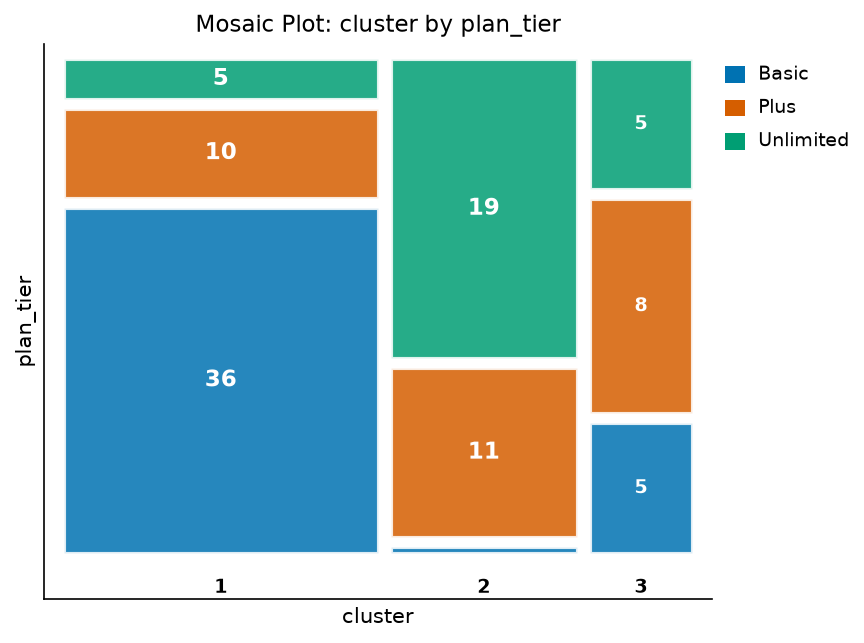

In [5]:
proc sort data=scored out=scored_keys(keep=cust_id cluster);
    by cust_id;
run;

proc sort data=subscribers out=subs_sorted;
    by cust_id;
run;

data profile;
    merge subs_sorted(in=a) scored_keys(in=b);
    by cust_id;
    if a and b;
run;

proc means data=profile mean std min max maxdec=1;
    class cluster;
    var tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    title 'Segment Profiles: Average Usage by Cluster (Original Units)';
run;

proc freq data=profile;
    tables cluster * plan_tier / nocol nopercent;
    title 'Plan-Tier Mix Within Each Segment';
run;

## Step 6 - Re-apply the model to next month's snapshot

A segmentation is only useful if it can be re-applied without re-running the whole job. The centroids we saved to `SEG_SEEDS` in Step 4 are a portable model: feeding them back as `SEED=SEG_SEEDS` with `MAXITER=0` tells FASTCLUS to *assign* each observation to its nearest saved centroid without moving the centroids - pure scoring, not re-fitting. Here we re-score the same standardized snapshot to confirm the exported model reproduces the original assignments; in production you would point `DATA=` at next month's standardized snapshot instead.

                                           Plan-Tier Mix Within Each Segment                                            


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952



NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


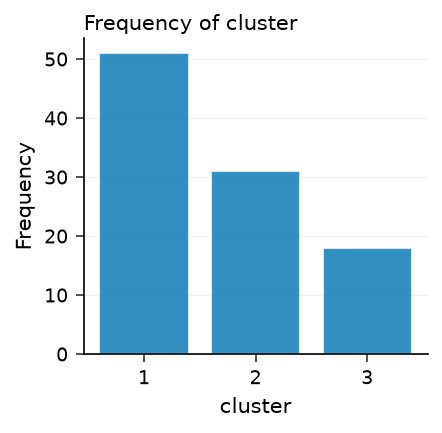

In [6]:
proc fastclus data=subs_std maxclusters=3 maxiter=0 seed=seg_seeds
        out=rescored;
    var tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    title 'Scoring a New Snapshot from the Exported Centroids';
run;

proc freq data=rescored;
    tables cluster / nocum;
    title 'Subscribers Re-Scored via the Exported Model';
run;

## Interpreting the results

FASTCLUS recovered the three behavioral segments embedded in the data, and the profiling tables translate them into a retention playbook. Read the segment numbers off the *Segment Profiles* table above - the cluster labels are arbitrary, so identify each persona by its usage signature:

- **Light / value users** - low data, modest bills, longer tenure, very few support calls, mostly on *Basic*. These customers are stable and price-sensitive; the right move is to *protect margin*, not discount. A right-sized plan recommendation prevents bill shock without giveaways.
- **Heavy-data streamers** - high data, high voice and international minutes, premium bills, mostly *Unlimited*. They are loyal and high-value: the play is *upsell and device upgrades*, plus proactive network-quality messaging so a competitor's promo cannot pry them loose.
- **High-touch / at-risk** - short tenure, elevated support-call volume, mid-tier spend. The frequent care contacts plus low tenure are classic churn precursors. This is the segment that earns a *proactive retention offer* and a service-recovery follow-up.

Key procedure choices that made this reliable: **PROC STDIZE** kept large-magnitude voice minutes from swamping the support-call signal; the pseudo-F sweep justified the cluster count rather than guessing it; the `FREQ` weight made multi-line family accounts count in proportion to their footprint; and the `OUTSEED=`/`SEED=` round-trip exported the centroids so the marketing team can re-segment each monthly snapshot with a single `MAXITER=0` FASTCLUS call - no re-clustering required.